In [ ]:
import os
import copy
import csv
import json
from datetime import datetime
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import rasterio
from rasterio.transform import xy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import geopandas as gpd
from shapely.geometry import Point

import wandb

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False

set_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# Early stopping class

In [ ]:
class EarlyStopping:
    def __init__(self, patience=30, delta=0.001): # was 20 for first run
        self.patience     = patience
        self.delta        = delta
        self.counter      = 0
        self.best_score   = None
        self.best_weights = None
        self.early_stop   = False

    def __call__(self, score, model):
        """score is a loss/error -- lower is better."""
        if self.best_score is None or score < self.best_score - self.delta:
            self.best_score   = score
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter      = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


# Loss Functions

In [ ]:
# class QuantileLoss(nn.Module):
#     def __init__(self, quantile=0.9):
#         super().__init__()
#         self.quantile = quantile

#     def forward(self, pred, target):
#         error = target - pred
#         return torch.max(self.quantile * error, (self.quantile - 1) * error).mean()

In [ ]:
class WeibullWeightedMSELoss(nn.Module):
    def __init__(self, kappa=28.0, alpha=2.75, eps=1e-6):
        super().__init__()
        self.kappa = kappa
        self.alpha = alpha
        self.eps = eps

    def forward(self, preds, targets):
        k, a = self.kappa, self.alpha
        pdf = (k/a) * ((targets/a)**(k-1)) * torch.exp(-(targets/a)**k)
        weights = 1.0 / (pdf + self.eps)
        weights = weights / weights.mean()
        return (weights * (preds - targets)**2).mean()

In [ ]:
class WeightedMSELoss(nn.Module):
    """MSE loss with linear weights based on target value.
    Pixels with higher CISI values receive proportionally higher weight,
    forcing the model to focus on city pixels without a custom distribution shape.
    weight = 1 + scale * target  (base weight 1 for all pixels, extra for high CISI)
    """
    def __init__(self, scale=5.0):
        super().__init__()
        self.scale = scale

    def forward(self, preds, targets):
        weights = 1.0 + self.scale * targets
        weights = weights / weights.mean()
        return (weights * (preds - targets) ** 2).mean()


In [ ]:
# Weibull loss weight visualization
# import numpy as np
# import matplotlib.pyplot as plt

# eps = 1e-6
# cisi = np.linspace(0.001, 1.0, 500)

# Configurations to compare
# configs = [
#     {'kappa': 5,  'alpha': 2.75, 'label': 'kappa=5,  alpha=2.75'},
#     {'kappa': 15, 'alpha': 2.75, 'label': 'kappa=15, alpha=2.75'},
#     {'kappa': 28, 'alpha': 2.75, 'label': 'kappa=28, alpha=2.75 (default)'},
#     {'kappa': 45, 'alpha': 2.75, 'label': 'kappa=45, alpha=2.75'},
#     {'kappa': 28, 'alpha': 1.5,  'label': 'kappa=28, alpha=1.5'},
#     {'kappa': 28, 'alpha': 5.0,  'label': 'kappa=28, alpha=5.0'},
# ]

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# for cfg in configs:
#     k, a = cfg['kappa'], cfg['alpha']
#     pdf     = (k / a) * ((cisi / a) ** (k - 1)) * np.exp(-(cisi / a) ** k)
#     weights = 1.0 / (pdf + eps)
#     weights = weights / weights.mean()
#     ls = '-' if cfg['alpha'] == 2.75 else '--'
#     axes[0].plot(cisi, pdf,     label=cfg['label'], linestyle=ls)
#     axes[1].plot(cisi, weights, label=cfg['label'], linestyle=ls)

# axes[0].axvline(0.15, color='grey', linestyle=':', linewidth=1, label='city threshold (0.15)')
# axes[1].axvline(0.15, color='grey', linestyle=':', linewidth=1, label='city threshold (0.15)')
# axes[1].axhline(1.0,  color='black', linestyle=':', linewidth=0.8, alpha=0.5, label='weight=1 (neutral)')

# axes[0].set_title('Weibull PDF')
# axes[0].set_xlabel('CISI value')
# axes[0].set_ylabel('Probability density')
# axes[0].legend(fontsize=8)

# axes[1].set_title('Loss weights (1 / PDF)  --  higher = model penalized more')
# axes[1].set_xlabel('CISI value')
# axes[1].set_ylabel('Normalized weight')
# axes[1].set_ylim(0, 15)
# axes[1].legend(fontsize=8)

# plt.tight_layout()
# plt.savefig('weibull_loss_weights.png', dpi=150, bbox_inches='tight')
# plt.show()


In [ ]:
# class WeightedMSELoss(nn.Module):
#     def __init__(self, threshold=0.2, factor=25):
#         super().__init__()
#         self.threshold = threshold
#         self.factor = factor

#     def forward(self, predictions, targets):
#         weights = torch.where(
#             targets > self.threshold,
#             torch.ones_like(targets) * self.factor,
#             torch.ones_like(targets)
#         )
#         return (weights * (predictions - targets) ** 2).mean()

In [ ]:
# class AsymmetricMSELoss(nn.Module):
#     def __init__(self, under_penalty=5.0):
#         super().__init__()
#         self.under_penalty = under_penalty
    
#     def forward(self, pred, target):
#         error = pred - target
#         loss = torch.where(error < 0,
#                           self.under_penalty * error ** 2,  # Under: 5× penalty
#                           error ** 2)                        # Over: 1× penalty
#         return loss.mean()

In [ ]:
# class ContinuousWeightedMSELoss(nn.Module):
#     def __init__(self, base=1.0, scale=20.0):
#         super().__init__()
#         self.base = base
#         self.scale = scale

#     def forward(self, preds, targets):
#         weights = self.base + self.scale * targets
#         return (weights * (preds - targets) ** 2).mean()

In [ ]:
# class HuberLoss(nn.Module):
#     def __init__(self, delta=0.1):
#         """
#         Huber Loss - robust to outliers
        
#         Args:
#             delta: Threshold where loss transitions from quadratic to linear
#                    Smaller delta = more robust to outliers
#         """
#         super().__init__()
#         self.delta = delta
    
#     def forward(self, pred, target):
#         error = torch.abs(pred - target)
        
#         # Quadratic for small errors, linear for large errors
#         quadratic = 0.5 * error ** 2
#         linear = self.delta * (error - 0.5 * self.delta)
        
#         loss = torch.where(error <= self.delta, quadratic, linear)
        
#         return loss.mean()

# CNN Model

In [ ]:
# class CNN(nn.Module):
#     def __init__(self, config):
#         super(CNN, self).__init__()

#         self.conv_layers = nn.Sequential(
#             nn.Conv2d(9, 16, kernel_size=3, padding=1),
#             nn.BatchNorm2d(16),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.MaxPool2d(2, 2),

#             nn.Conv2d(16, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.MaxPool2d(2, 2),

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.MaxPool2d(2, 2),

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#         )

#         self.fc_layers = nn.Sequential(
#             nn.Linear(128, 32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.Linear(32, 1),
#         )

#     def forward(self, x):
#         x = self.conv_layers(x)
#         x = x[:, :, 1, 1]
#         x = self.fc_layers(x)
#         return torch.sigmoid(x)

# Dataset Class

## Stage 5 — Data Augmentation (augment=True)

City pixels (CISI > 0.15) account for only ~2% of training samples. Rather than changing the sampling distribution, data augmentation increases the **spatial diversity** of city patches by applying a random 90°/180°/270° rotation to each city patch every time it is drawn.

- Augmentation is applied per-sample at load time, so each epoch the model sees each city pixel from a different orientation.
- Rural patches (CISI ≤ 0.15) are never rotated — their value is dominated by large homogeneous land-cover areas where rotation would be redundant.
- The val/test loaders always use `augment=False` so evaluation remains deterministic.
- Two separate `CISIDataset` instances share the same `valid_indices` and split indices; only the train instance has `augment=True`.

In [ ]:
class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path, patch_size=16, eu_mask_path=None, augment=False):
        with rasterio.open(gdp_path) as src:
            self.gdp = src.read(1).astype(np.float32)
        with rasterio.open(pop_path) as src:
            self.pop = src.read(1).astype(np.float32)
        with rasterio.open(lc_path) as src:
            self.lc = src.read().astype(np.float32)
        with rasterio.open(cisi_path) as src:
            self.cisi = src.read(1).astype(np.float32)

        self.patch_size = patch_size
        self.augment    = augment

        base_mask = ~np.isnan(self.gdp) & ~np.isnan(self.pop) & ~np.isnan(self.cisi)

        if eu_mask_path is not None:
            with rasterio.open(eu_mask_path) as src:
                eu_mask = src.read(1).astype(bool)
            base_mask = base_mask & eu_mask
            print('EU mask applied: Italy and non-EU countries excluded')

        self.valid_mask    = base_mask
        self.valid_indices = np.argwhere(self.valid_mask)
        print(f"Found {len(self.valid_indices):,} valid pixels (patch_size={patch_size})")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        patch_size = self.patch_size
        half_patch = patch_size // 2
        max_tries  = 50
        tries      = 0

        orig_i, orig_j = self.valid_indices[idx]

        while True:
            i, j = self.valid_indices[idx]

            pad_top    = max(0, half_patch - i)
            pad_bottom = max(0, (i + half_patch) - self.gdp.shape[0])
            pad_left   = max(0, half_patch - j)
            pad_right  = max(0, (j + half_patch) - self.gdp.shape[1])

            i_start = max(0, i - half_patch)
            i_end   = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch)
            j_end   = min(self.gdp.shape[1], j + half_patch)

            gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()

            if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
                pad = ((pad_top, pad_bottom), (pad_left, pad_right))
                gdp_patch = np.pad(gdp_patch, pad, mode='edge')
                pop_patch = np.pad(pop_patch, pad, mode='edge')
                lc_patch  = np.pad(lc_patch, ((0, 0), *pad), mode='edge')

            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break

            tries += 1
            if tries >= max_tries:
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break
            idx = np.random.randint(0, len(self.valid_indices))

        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        target = self.cisi[orig_i, orig_j]

        # Random 90°/180°/270° rotation applied only to city patches during training
        if self.augment and target > 0.15:
            k = np.random.randint(0, 4)
            if k > 0:
                input_tensor = np.rot90(input_tensor, k=k, axes=(1, 2)).copy()

        return torch.FloatTensor(input_tensor), torch.FloatTensor([target]), (orig_i, orig_j)

In [ ]:
# class CISIDataset(Dataset):
#     def __init__(self, gdp_path, pop_path, lc_path, cisi_path, patch_size=16, eu_mask_path=None):
#         with rasterio.open(gdp_path) as src:
#             self.gdp = src.read(1).astype(np.float32)
#         with rasterio.open(pop_path) as src:
#             self.pop = src.read(1).astype(np.float32)
#         with rasterio.open(lc_path) as src:
#             self.lc = src.read().astype(np.float32)
#         with rasterio.open(cisi_path) as src:
#             self.cisi = src.read(1).astype(np.float32)
#
#         self.patch_size = patch_size
#
#         base_mask = ~np.isnan(self.gdp) & ~np.isnan(self.pop) & ~np.isnan(self.cisi)
#
#         if eu_mask_path is not None:
#             with rasterio.open(eu_mask_path) as src:
#                 eu_mask = src.read(1).astype(bool)
#             base_mask = base_mask & eu_mask
#             print('EU mask applied: Italy and non-EU countries excluded')
#
#         self.valid_mask    = base_mask
#         self.valid_indices = np.argwhere(self.valid_mask)
#         print(f"Found {len(self.valid_indices):,} valid pixels (patch_size={patch_size})")
#
#     def __len__(self):
#         return len(self.valid_indices)
#
#     def __getitem__(self, idx):
#         patch_size = self.patch_size
#         half_patch = patch_size // 2
#         max_tries  = 50
#         tries      = 0
#
#         orig_i, orig_j = self.valid_indices[idx]
#
#         while True:
#             i, j = self.valid_indices[idx]
#
#             pad_top    = max(0, half_patch - i)
#             pad_bottom = max(0, (i + half_patch) - self.gdp.shape[0])
#             pad_left   = max(0, half_patch - j)
#             pad_right  = max(0, (j + half_patch) - self.gdp.shape[1])
#
#             i_start = max(0, i - half_patch)
#             i_end   = min(self.gdp.shape[0], i + half_patch)
#             j_start = max(0, j - half_patch)
#             j_end   = min(self.gdp.shape[1], j + half_patch)
#
#             gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
#             pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
#             lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()
#
#             if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
#                 pad = ((pad_top, pad_bottom), (pad_left, pad_right))
#                 gdp_patch = np.pad(gdp_patch, pad, mode='edge')
#                 pop_patch = np.pad(pop_patch, pad, mode='edge')
#                 lc_patch  = np.pad(lc_patch, ((0, 0), *pad), mode='edge')
#
#             if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
#                 break
#
#             tries += 1
#             if tries >= max_tries:
#                 gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
#                 pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
#                 break
#             idx = np.random.randint(0, len(self.valid_indices))
#
#         input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
#         target = self.cisi[orig_i, orig_j]
#
#         return torch.FloatTensor(input_tensor), torch.FloatTensor([target]), (orig_i, orig_j)

# Save function

In [ ]:
# import torch
# import json
# from datetime import datetime
# import os

# def save_model_checkpoint(model, optimizer, train_losses, val_losses, config, save_name, 
#                          dataset, train_dataset, val_dataset, criterion, 
#                          learning_rate, batch_size, num_epochs, patch_size):
    
#     os.makedirs('models', exist_ok=True)
#     save_path = f'models/cisi_model_{save_name}.pth'
    
#     checkpoint = {
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'train_loss': train_losses,
#         'val_loss': val_losses,
#         'epoch': len(train_losses),
#         'best_val_loss': min(val_losses) if val_losses else float('inf'),
#         'config': config,
#         'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
#         'dataset_info': {
#             'patch_size': patch_size,
#             'train_samples': len(train_dataset),
#             'val_samples': len(val_dataset),
#             'total_pixels': len(dataset.valid_indices) if hasattr(dataset, 'valid_indices') else len(dataset),
#         },
#         'training_info': {
#             'loss_function': type(criterion).__name__,
#             'learning_rate': learning_rate,
#             'batch_size': batch_size,
#             'num_epochs': num_epochs,
#             'optimizer': type(optimizer).__name__,
#         },
#     }
    
#     torch.save(checkpoint, save_path)
#     print(f"Saved: {save_path}")

# Training Function

In [ ]:
# def training(
#     num_epochs,
#     model,
#     train_loader,
#     val_loader,
#     criterion,
#     optimizer,
#     clip_value,
#     device,
#     scheduler=None,
#     wandbrun=None,
#     sigmoidcnn=False
# ):
#     train_loss_list = []
#     val_loss_list = []

#     early_stopping = EarlyStopping()

#     for epoch in range(num_epochs):
        # ========== TRAINING ==========
#         model.train()
#         running_loss = 0.0

#         for batch in train_loader:
#             inputs, targets, _ = batch
#             inputs = inputs.to(device)
#             targets = targets.to(device).view(-1, 1)

#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
#             optimizer.step()

#             running_loss += loss.item()

#         avg_train_loss = running_loss / len(train_loader)
#         train_loss_list.append(avg_train_loss)

        # ========== VALIDATION ==========
#         model.eval()
#         val_loss = 0.0

#         with torch.no_grad():
#             for batch in val_loader:
#                 inputs, targets, _ = batch
#                 inputs = inputs.to(device)
#                 targets = targets.to(device).view(-1, 1)

#                 outputs = model(inputs)
#                 loss = criterion(outputs, targets)
#                 val_loss += loss.item()

#         avg_val_loss = val_loss / len(val_loader)
#         val_loss_list.append(avg_val_loss)

#         current_lr = optimizer.param_groups[0]['lr']
#         print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {current_lr:.6f}")

        # ========== SCHEDULER ========== 
#         if scheduler is not None:
#             scheduler.step()

        # Early stopping check
#         early_stopping(avg_val_loss)
#         if early_stopping.early_stop:
#             print("Early stopping triggered!")
#             break

#     return train_loss_list, val_loss_list

# Paths 0.10

In [ ]:
gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif"
pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif"
lc_path = r"READY_data\landuse_onehot\clipped_history_2020_onehot.tif"
cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"
eu_mask_path = r"READY_data\labels\eu_mask_010deg_ex_italy.tif"  # EU27 excl. Italy (test set)


## Geographical split: train / val / test

- Training and validation pixels are drawn from EU27 (Italy excluded) using a stratified 80/20 random split
- Stratification is on CISI > 0.15 to ensure city pixels are represented in both splits
- Train and val pixels are spatially interleaved — the split is not geographical
- Test pixels are all valid CISI pixels in Italy, a fully held-out region the model never sees during training


EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=16)


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_18832\2711370018.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  italy_geom = world[world['NAME'] == 'Italy'].geometry.unary_union


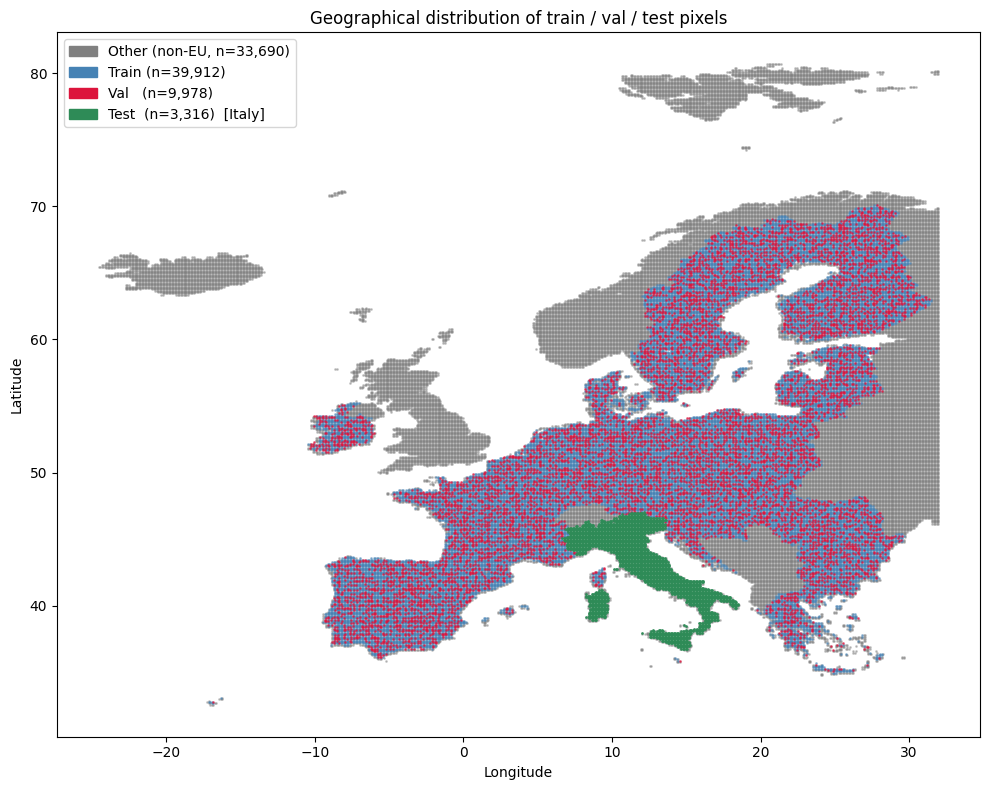

In [ ]:
# Geographical representation of train / val / test split

# Load raster metadata
with rasterio.open(cisi_path) as src:
    transform = src.transform
    cisi_full = src.read(1).astype('float32')

# Build dataset (EU27 excl. Italy)
_ds = CISIDataset(gdp_path, pop_path, lc_path, cisi_path, patch_size=16, eu_mask_path=eu_mask_path)
cisi_vals = np.array([_ds.cisi[i, j] for i, j in _ds.valid_indices])

# Reproduce stratified 80/20 split
high_threshold = 0.15
high_idx = np.where(cisi_vals > high_threshold)[0]
low_idx  = np.where(cisi_vals <= high_threshold)[0]
np.random.seed(42)
np.random.shuffle(high_idx)
np.random.shuffle(low_idx)
train_idx = np.concatenate([high_idx[:int(0.8*len(high_idx))], low_idx[:int(0.8*len(low_idx))]])
val_idx   = np.concatenate([high_idx[int(0.8*len(high_idx)):], low_idx[int(0.8*len(low_idx)):]])

def idx_to_lonlat(indices, transform):
    xs, ys = rasterio.transform.xy(transform, indices[:, 0], indices[:, 1])
    return np.array(xs), np.array(ys)

# Load EU mask
with rasterio.open(eu_mask_path) as src:
    eu_mask_arr = src.read(1).astype(bool)

# Italy pixels: use country shapefile to isolate Italy exactly
world = gpd.read_file(r'ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')[['NAME', 'geometry']]
italy_geom = world[world['NAME'] == 'Italy'].geometry.unary_union

cisi_valid = ~np.isnan(cisi_full)
outside_eu = cisi_valid & ~eu_mask_arr
all_outside_idx = np.argwhere(outside_eu)
out_xs, out_ys = idx_to_lonlat(all_outside_idx, transform)
is_italy = np.array([italy_geom.contains(Point(x, y)) for x, y in zip(out_xs, out_ys)])
italy_idx   = all_outside_idx[is_italy]
other_idx   = all_outside_idx[~is_italy]

# Coordinates
train_lon, train_lat = idx_to_lonlat(_ds.valid_indices[train_idx], transform)
val_lon,   val_lat   = idx_to_lonlat(_ds.valid_indices[val_idx],   transform)
test_lon,  test_lat  = idx_to_lonlat(italy_idx,                    transform)
other_lon, other_lat = idx_to_lonlat(other_idx,                    transform)

# Plot -- layer order: grey other → blue train → red val → green Italy
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('white')

ax.scatter(other_lon, other_lat, s=1, c='grey',      alpha=0.4, rasterized=True)
ax.scatter(train_lon, train_lat, s=1, c='steelblue', alpha=0.5, rasterized=True)
ax.scatter(val_lon,   val_lat,   s=1, c='crimson',   alpha=0.6, rasterized=True)
ax.scatter(test_lon,  test_lat,  s=1, c='seagreen',  alpha=0.9, rasterized=True)

handles = [
    mpatches.Patch(color='grey',      label=f'Other (non-EU, n={len(other_idx):,})'),
    mpatches.Patch(color='steelblue', label=f'Train (n={len(train_idx):,})'),
    mpatches.Patch(color='crimson',   label=f'Val   (n={len(val_idx):,})'),
    mpatches.Patch(color='seagreen',  label=f'Test  (n={len(italy_idx):,})  [Italy]'),
]
ax.legend(handles=handles, markerscale=6, fontsize=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographical distribution of train / val / test pixels')
plt.tight_layout()
plt.savefig('train_val_test_split_map.png', dpi=150, bbox_inches='tight')
plt.show()


## CISI distributions: train / val / test

- Left panel shows the full distribution (0-1); train and val should look identical due to stratified sampling
- Right panel zooms into city pixels (CISI > 0.15) to check whether Italy's urban distribution matches the training data
- A large mismatch between test and train city distributions would indicate domain shift and limit test set validity


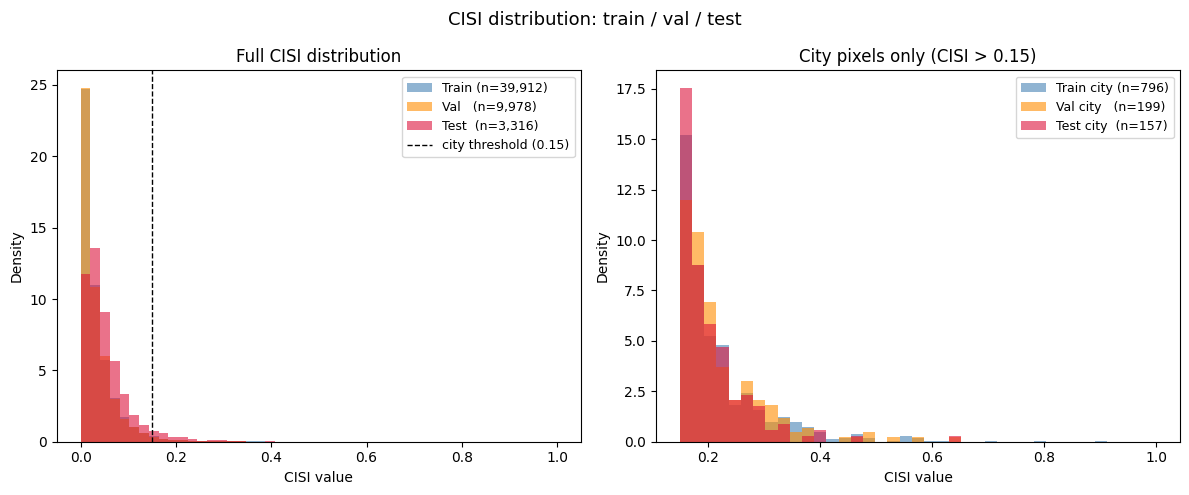

Train  mean=0.033  median=0.020  city%=2.0%  city_mean=0.222
Val    mean=0.033  median=0.020  city%=2.0%  city_mean=0.221
Test   mean=0.052  median=0.040  city%=4.7%  city_mean=0.206


In [ ]:
# CISI value distributions for train / val / test pixels

# Get CISI values for each split (reuses _ds, train_idx, val_idx, italy_idx from geo plot cell)
train_cisi = cisi_vals[train_idx]
val_cisi   = cisi_vals[val_idx]
test_cisi  = np.array([cisi_full[i, j] for i, j in italy_idx])
test_cisi  = test_cisi[~np.isnan(test_cisi)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: full distribution ---
bins = np.linspace(0, 1, 50)
axes[0].hist(train_cisi, bins=bins, color='steelblue',  alpha=0.6, density=True, label=f'Train (n={len(train_cisi):,})')
axes[0].hist(val_cisi,   bins=bins, color='darkorange', alpha=0.6, density=True, label=f'Val   (n={len(val_cisi):,})')
axes[0].hist(test_cisi,  bins=bins, color='crimson',    alpha=0.6, density=True, label=f'Test  (n={len(test_cisi):,})')
axes[0].axvline(0.15, color='black', linestyle='--', linewidth=1, label='city threshold (0.15)')
axes[0].set_xlabel('CISI value')
axes[0].set_ylabel('Density')
axes[0].set_title('Full CISI distribution')
axes[0].legend(fontsize=9)

# --- Right: city pixels only (CISI > 0.15) ---
bins_city = np.linspace(0.15, 1, 40)
axes[1].hist(train_cisi[train_cisi > 0.15], bins=bins_city, color='steelblue',  alpha=0.6, density=True, label=f'Train city (n={( train_cisi > 0.15).sum():,})')
axes[1].hist(val_cisi[val_cisi > 0.15],     bins=bins_city, color='darkorange', alpha=0.6, density=True, label=f'Val city   (n={(val_cisi   > 0.15).sum():,})')
axes[1].hist(test_cisi[test_cisi > 0.15],   bins=bins_city, color='crimson',    alpha=0.6, density=True, label=f'Test city  (n={(test_cisi  > 0.15).sum():,})')
axes[1].set_xlabel('CISI value')
axes[1].set_ylabel('Density')
axes[1].set_title('City pixels only (CISI > 0.15)')
axes[1].legend(fontsize=9)

plt.suptitle('CISI distribution: train / val / test', fontsize=13)
plt.tight_layout()
plt.savefig('train_val_test_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
for name, arr in [('Train', train_cisi), ('Val', val_cisi), ('Test', test_cisi)]:
    city = arr[arr > 0.15]
    print(f'{name:5s}  mean={arr.mean():.3f}  median={np.median(arr):.3f}  '
          f'city%={100*len(city)/len(arr):.1f}%  city_mean={city.mean():.3f}')


In [ ]:
# with rasterio.open(r'READY_data\labels\2024_CISI_010deg_nearest.tif') as src:
#     data = src.read(1)
#     print(f"Shape: {data.shape}")
#     print(f"Max: {np.nanmax(data):.4f}")

# Paths 0.25

In [ ]:
# gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif"
# pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif"
# lc_path = r"READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif"
# cisi_path = r"READY_data\labels\CISI_025deg_corrected.tif"

In [ ]:
# with rasterio.open(r'READY_data\labels\CISI_025deg_corrected.tif') as src:
#     data = src.read(1)
#     print(f"Shape: {data.shape}")
#     print(f"Max: {np.nanmax(data):.4f}")

# Dataset and Split

In [ ]:
# dataset = CISIDataset(gdp_path, pop_path, lc_path, cisi_path, eu_mask_path=eu_mask_path)
# cisi_values = np.array([dataset.cisi[i, j] for i, j in dataset.valid_indices])

# high_threshold = 0.15
# high_indices = np.where(cisi_values > high_threshold)[0]
# low_indices  = np.where(cisi_values <= high_threshold)[0]

# np.random.seed(42)
# np.random.shuffle(high_indices)
# np.random.shuffle(low_indices)

# train_idx = np.concatenate([high_indices[:int(0.8*len(high_indices))],
#                              low_indices[:int(0.8*len(low_indices))]])
# val_idx   = np.concatenate([high_indices[int(0.8*len(high_indices)):],
#                              low_indices[int(0.8*len(low_indices)):]])

# train_dataset = Subset(dataset, train_idx)
# val_dataset   = Subset(dataset, val_idx)

# print(f"Train: {len(train_dataset):,}, Val: {len(val_dataset):,}")

# cisi_train = cisi_values[train_idx]
# n_high = (cisi_train > high_threshold).sum()
# n_low  = (cisi_train <= high_threshold).sum()
# w_high = len(cisi_train) / n_high
# w_low  = len(cisi_train) / n_low
# sample_weights = np.where(cisi_train > high_threshold, w_high, w_low)
# print(f"Sampler weights — high: {w_high:.1f}x, low: {w_low:.2f}x")

# Create Dataloaders

In [ ]:
# batch_size = 32

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=True)
# val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=True)

In [ ]:
# train_targets = []
# val_targets = []

# for _, target, _ in train_loader:
#     train_targets.extend(target.numpy().flatten())

# for _, target, _ in val_loader:
#     val_targets.extend(target.numpy().flatten())

# train_targets = np.array(train_targets)
# val_targets = np.array(val_targets)

# print("TRAIN SET:")
# print(f"  Mean: {train_targets.mean():.4f}, Std: {train_targets.std():.4f}")
# print(f"  Range: [{train_targets.min():.4f}, {train_targets.max():.4f}]")

# print("\nVAL SET:")
# print(f"  Mean: {val_targets.mean():.4f}, Std: {val_targets.std():.4f}")
# print(f"  Range: [{val_targets.min():.4f}, {val_targets.max():.4f}]")

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].hist(train_targets, bins=50, alpha=0.7, label='Train')
# axes[0].set_title('Train CISI Distribution')
# axes[0].set_xlabel('CISI')

# axes[1].hist(val_targets, bins=50, alpha=0.7, label='Val', color='orange')
# axes[1].set_title('Validation CISI Distribution')
# axes[1].set_xlabel('CISI')

# plt.tight_layout()
# plt.show()

# Init Model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# config = {'dropout': 0.3}
# model = CNN(config).to(device)
# criterion = WeibullWeightedMSELoss(kappa=28.0, alpha=2.75)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

Using device: cpu


# Train Model

In [ ]:
# vars
# nummber_of_epochs = 50

In [ ]:
# train_loss_list, val_loss_list = training(
#     num_epochs=nummber_of_epochs,
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     criterion=criterion,
#     optimizer=optimizer,
#     clip_value=1.0,
#     device=device,
#     scheduler=scheduler
# )

# Plotting some results

In [ ]:
# plt.figure(figsize=(10, 5))
# plt.plot(train_loss_list, label='Train Loss')
# plt.plot(val_loss_list, label='Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.title('Training Progress')
# plt.show()

# Full Dataset Evaluation

In [ ]:
# model.eval()
# all_preds, all_targets = [], []

# with torch.no_grad():
#     for batch in val_loader:
#         inputs, targets, _ = batch
#         inputs = inputs.to(device)
#         outputs = model(inputs)
#         all_preds.append(outputs.cpu())
#         all_targets.append(targets)

# preds   = torch.cat(all_preds).numpy().flatten()
# targets = torch.cat(all_targets).numpy().flatten()

# from sklearn.metrics import r2_score, mean_absolute_error
# print(f"Pred range:            {preds.min():.4f} - {preds.max():.4f}")
# print(f"Pred mean:             {preds.mean():.4f}  (target mean: {targets.mean():.4f})")
# print(f"High CISI pred mean:   {preds[targets > 0.15].mean():.4f}")
# print(f"High CISI target mean: {targets[targets > 0.15].mean():.4f}")
# print(f"City underprediction:  {(1 - preds[targets>0.2].mean()/targets[targets>0.2].mean())*100:.1f}%")
# print(f"\nGlobal R2:  {r2_score(targets, preds):.4f}")
# print(f"Global MAE: {mean_absolute_error(targets, preds):.4f}")
# print(f"City R2:    {r2_score(targets[targets>0.2], preds[targets>0.2]):.4f}")
# print(f"City MAE:   {mean_absolute_error(targets[targets>0.2], preds[targets>0.2]):.4f}")

In [ ]:
# Load best model (Exp102)
# model.eval()
# all_preds = []
# all_targets = []

# with torch.no_grad():
#     for batch in val_loader:
#         inputs, targets, _ = batch
#         inputs = inputs.to(device)
#         outputs = model(inputs)
#         all_preds.append(outputs.cpu())
#         all_targets.append(targets)

# preds = torch.cat(all_preds).numpy().flatten()
# targets = torch.cat(all_targets).numpy().flatten()

# Diagnostics
# print(f"Pred range: {preds.min():.4f} - {preds.max():.4f}")
# print(f"Pred mean: {preds.mean():.4f}")
# print(f"Target mean: {targets.mean():.4f}")
# print(f"High CISI pixels (>0.2): {(targets > 0.2).mean()*100:.1f}%")
# print(f"High CISI pred mean: {preds[targets > 0.2].mean():.4f}")
# print(f"High CISI target mean: {targets[targets > 0.2].mean():.4f}")

# Generate predictions

In [ ]:
# # W&B Hyperparameter Sweep

# Uses Weights & Biases `wandb.sweep` with Bayesian optimisation (method=bayes).

# **Search space:**
# - `lr`: log-uniform 1e-5 to 5e-3
# - `weight_decay`: log-uniform 1e-6 to 1e-3
# - `batch_size`: 16, 32, 64
# - `dropout`: 0.1, 0.2, 0.3, 0.4
# - `patch_size`: 8, 16, 32
# - `n_layers`: 2, 3, 4
# - `base_channels`: 8, 16, 32
# - `loss_fn`: weibull, huber, mse
# - `kappa`: uniform 5 to 60 (Weibull shape, used when loss_fn=weibull)
# - `alpha`: uniform 1.5 to 5.0 (Weibull scale, used when loss_fn=weibull)

# **Metric to optimise:** `city_mae` (MAE on CISI > 0.15 pixels), minimise.

# Per epoch: `val_loss` and `val_city_mae` are logged so W&B shows a real error curve.

# Run `wandb.agent(sweep_id, train_sweep, count=100)` to launch 100 trials.


# Visualize Results

In [ ]:
# plt.figure(figsize=(8, 8))
# plt.scatter(actuals, predictions, alpha=0.5, s=10)
# plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
# plt.xlabel('Actual CISI')
# plt.ylabel('Predicted CISI')
# plt.title('Predictions vs Actuals')
# plt.legend()
# plt.grid(True)
# plt.show()

def train_sweep():
    run = wandb.init()
    cfg = run.config

    patch_size  = cfg.patch_size
    batch_size  = cfg.batch_size

    sweep_dataset = CISIDataset(
        gdp_path, pop_path, lc_path, cisi_path,
        patch_size=patch_size, eu_mask_path=eu_mask_path
    )
    n = len(sweep_dataset)
    n_train = int(0.8 * n)
    n_val   = n - n_train
    train_ds, val_ds = torch.utils.data.random_split(
        sweep_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    s_train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    s_val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    model = CNNSweep(dict(cfg)).to(device)
    criterion = build_criterion(dict(cfg))
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
    es = EarlyStopping(patience=15, delta=0.0001)

    for epoch in range(100):
        model.train()
        for inputs, targets, _ in s_train_loader:
            inputs, targets = inputs.to(device), targets.to(device).view(-1, 1)
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Val pass: compute loss + city_mae in one forward pass
        model.eval()
        val_losses, ep_preds, ep_targets = [], [], []
        with torch.no_grad():
            for inputs, targets, _ in s_val_loader:
                inputs, targets_dev = inputs.to(device), targets.to(device).view(-1, 1)
                out = model(inputs)
                val_losses.append(criterion(out, targets_dev).item())
                ep_preds.extend(out.cpu().numpy().flatten())
                ep_targets.extend(targets.numpy().flatten())

        ep_preds   = np.array(ep_preds)
        ep_targets = np.array(ep_targets)
        val_loss   = float(np.mean(val_losses))
        city_mask_ep = ep_targets > 0.15
        city_mae_ep  = float(mean_absolute_error(ep_targets[city_mask_ep], ep_preds[city_mask_ep])) \
                       if city_mask_ep.sum() > 10 else 999.0

        wandb.log({'val_loss': val_loss, 'val_city_mae': city_mae_ep, 'epoch': epoch})
        scheduler.step()

        es(city_mae_ep, model)
        if es.early_stop:
            print('Early stop at epoch', epoch)
            break

    # Final evaluation on best weights
    model.load_state_dict(es.best_weights)
    model.eval()
    preds, targets_all = [], []
    with torch.no_grad():
        for inputs, targets, _ in s_val_loader:
            preds.extend(model(inputs.to(device)).cpu().numpy().flatten())
            targets_all.extend(targets.numpy().flatten())

    preds       = np.array(preds)
    targets_all = np.array(targets_all)
    city_mask   = targets_all > 0.15

    global_mae  = float(mean_absolute_error(targets_all, preds))
    global_rmse = float(np.sqrt(np.mean((targets_all - preds) ** 2)))
    city_mae    = float(mean_absolute_error(targets_all[city_mask], preds[city_mask])) if city_mask.sum() > 10 else 999.0
    city_rmse   = float(np.sqrt(np.mean((targets_all[city_mask] - preds[city_mask]) ** 2))) if city_mask.sum() > 10 else 999.0
    city_r2     = float(r2_score(targets_all[city_mask], preds[city_mask])) if city_mask.sum() > 10 else -999.0
    city_underpred = float(np.mean(targets_all[city_mask] - preds[city_mask])) if city_mask.sum() > 10 else 999.0

    wandb.log({
        'global_mae': global_mae, 'global_rmse': global_rmse,
        'city_mae': city_mae, 'city_rmse': city_rmse,
        'city_r2': city_r2, 'city_underprediction': city_underpred,
        'pred_max': float(preds.max()),
    })

    # Save best model across entire sweep
    global best_city_mae
    if city_mae < best_city_mae:
        best_city_mae = city_mae
        torch.save({
            'model_state_dict': es.best_weights,
            'config': dict(cfg),
            'city_mae': city_mae,
            'city_rmse': city_rmse,
            'global_mae': global_mae,
        }, BEST_MODEL_PATH)
        print('New best model -- city_mae=' + str(round(city_mae, 4)))

    # Append to CSV
    row = {
        'loss_fn': cfg.loss_fn, 'kappa': cfg.get('kappa', None), 'alpha': cfg.get('alpha', None),
        'lr': cfg.lr, 'dropout': cfg.dropout, 'patch_size': patch_size,
        'batch_size': batch_size, 'n_layers': cfg.n_layers, 'base_channels': cfg.base_channels,
        'weight_decay': cfg.weight_decay,
        'global_mae': global_mae, 'global_rmse': global_rmse,
        'city_mae': city_mae, 'city_rmse': city_rmse,
        'city_r2': city_r2, 'city_underprediction': city_underpred,
        'pred_max': float(preds.max()),
    }
    write_header = not os.path.exists(SWEEP_CSV)
    with open(SWEEP_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header: w.writeheader()
        w.writerow(row)

    run.finish()


In [ ]:
# mse = mean_squared_error(actuals, predictions)
# mae = mean_absolute_error(actuals, predictions)
# rmse = np.sqrt(mse)
# r2 = r2_score(actuals, predictions)

# print(f"MSE: {mse:.4f}")
# print(f"MAE: {mae:.4f}")
# print(f"RMSE: {rmse:.4f}")
# print(f"R² Score: {r2:.4f}")

In [ ]:
# Check distributions
# print("=== ACTUALS ===")
# print(f"Mean: {actuals.mean():.4f}")
# print(f"Std: {actuals.std():.4f}")
# print(f"Range: [{actuals.min():.4f}, {actuals.max():.4f}]")

# print("\n=== PREDICTIONS ===")
# print(f"Mean: {predictions.mean():.4f}")
# print(f"Std: {predictions.std():.4f}")
# print(f"Range: [{predictions.min():.4f}, {predictions.max():.4f}]")

# Plot histograms
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].hist(actuals, bins=50, alpha=0.7, label='Actuals')
# axes[0].set_title('Distribution of Actual CISI')
# axes[0].set_xlabel('CISI Value')
# axes[0].legend()

# axes[1].hist(predictions, bins=50, alpha=0.7, label='Predictions', color='orange')
# axes[1].set_title('Distribution of Predicted CISI')
# axes[1].set_xlabel('CISI Value')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

In [ ]:
# Look at one sample from dataset
# sample_input, sample_target, _ = dataset[0]

# print("Input shape:", sample_input.shape)
# print("\nInput statistics per channel:")
# for i in range(9):
#     channel = sample_input[i]
#     print(f"Channel {i}: min={channel.min():.2f}, max={channel.max():.2f}, mean={channel.mean():.2f}")

# print(f"\nTarget CISI value: {sample_target.item():.4f}")

# Generate Predictions on Full Training Set

In [ ]:
# # Generate predictions on ALL training data
# model.eval()
# all_preds = []
# all_actuals = []
# all_indices = []

# with torch.no_grad():
#     for inputs, targets, indices in train_loader:
#         inputs = inputs.to(device)
#         outputs = model(inputs)
        
#         all_preds.extend(outputs.cpu().numpy().flatten())
#         all_actuals.extend(targets.cpu().numpy().flatten())
#         all_indices.extend(indices)

# all_preds = np.array(all_preds)
# all_actuals = np.array(all_actuals)

# # Split by city/rural
# city_mask = all_actuals > 0.1
# rural_mask = all_actuals <= 0.1

# print(f"\n{'='*80}")
# print("TRAINING SET: CITY vs RURAL")
# print(f"{'='*80}")

# print(f"\n CITIES (CISI > 0.1):")
# print(f"  Count: {city_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[city_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[city_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[city_mask], all_preds[city_mask]):.4f}")

# print(f"\n RURAL (CISI ≤ 0.1):")
# print(f"  Count: {rural_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[rural_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[rural_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[rural_mask], all_preds[rural_mask]):.4f}")

# Save model

In [ ]:
# save_model_checkpoint(
#     model, optimizer, train_loss_list, val_loss_list, config,
#     save_name='exp111',
#     dataset=dataset,
#     train_dataset=train_dataset,
#     val_dataset=val_dataset,
#     criterion=criterion,
#     learning_rate=0.0005,
#     batch_size=batch_size,
#     num_epochs=nummber_of_epochs,
#     patch_size=32
# )

# W&B Hyperparameter Sweep

In [ ]:
# SWEEP_PROJECT   = 'cisi-hyperparameter-sweep'
# BEST_MODEL_PATH = 'best_sweep_model.pt'
# SWEEP_CSV       = 'sweep_results_7_5.csv'  # Stage 5 — data augmentation + val_city_rmse

# sweep_config = {
#     'method': 'bayes',
#     'metric': {'name': 'val_rmse', 'goal': 'minimize'},
#     'parameters': {
#         # Optimiser
#         'lr':           {'distribution': 'log_uniform_values', 'min': 1e-5, 'max': 1e-3},
#         'weight_decay': {'distribution': 'log_uniform_values', 'min': 1e-6, 'max': 1e-3},
#         'batch_size':   {'values': [16, 32]},
#         # Regularisation
#         'dropout':      {'values': [0.1, 0.2, 0.3]},
#         # Architecture 
#         'patch_size':   {'value': 8},
#         'n_layers':     {'values': [2, 3]},
#         'base_channels':{'value': 32},
#         # Loss function
#         'loss_fn':      {'values': ['weibull', 'huber', 'weighted_mse']},
#         # Weibull-specific (ignored when loss_fn != weibull)
#         'kappa':        {'values': [5.0, 15.0, 28.0, 45.0]},
#         'alpha':        {'values': [1.5, 2.0, 2.75, 3.5]},
#         # Huber-specific (ignored when loss_fn != huber)
#         'delta':        {'values': [0.05, 0.1, 0.2]},
#         # WeightedMSE-specific (ignored when loss_fn != weighted_mse)
#         'scale':        {'values': [5.0, 10.0, 20.0]},
#     }
# }

# sweep_id = wandb.sweep(sweep_config, project=SWEEP_PROJECT)
# print('Sweep ID:', sweep_id)

In [ ]:
class CNNSweep(nn.Module):
    """
    """
    def __init__(self, config):
        super().__init__()
        d            = config.get('dropout', 0.3)
        n_layers     = config.get('n_layers', 4)
        base_ch      = config.get('base_channels', 32)
        self.patch_size = config.get('patch_size', 16)

        layers = []
        in_ch  = 9
        out_ch = base_ch
        for i in range(n_layers):
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                nn.Dropout(d),
            ]
            # Add pooling on all but last layer
            if i < n_layers - 1:
                layers.append(nn.MaxPool2d(2, 2))
            in_ch  = out_ch
            out_ch = min(out_ch * 2, 256)  # cap at 256

        self.conv_layers = nn.Sequential(*layers)
        self.final_ch    = in_ch

        self.fc_layers = nn.Sequential(
            nn.Linear(self.final_ch, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(d),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        # adaptive center extraction
        x = x[:, :, x.shape[2] // 2, x.shape[3] // 2]
        x = self.fc_layers(x)
        return torch.sigmoid(x)


def build_criterion(cfg):
    loss_fn = cfg.get('loss_fn', 'weibull')
    if loss_fn == 'weibull':
        return WeibullWeightedMSELoss(kappa=cfg.get('kappa', 28.0), alpha=cfg.get('alpha', 2.75))
    elif loss_fn == 'huber':
        return nn.HuberLoss(delta=cfg.get('delta', 0.1))
    elif loss_fn == 'weighted_mse':
        return WeightedMSELoss(scale=cfg.get('scale', 5.0))
    else:  # mse
        return nn.MSELoss()


In [ ]:
def train_sweep():
    set_seed(42)
    run = wandb.init()
    wandb.define_metric('val_rmse', summary='min')
    wandb.define_metric('val_city_rmse', summary='min')
    cfg = run.config

    try:
        patch_size = cfg.patch_size
        batch_size = cfg.batch_size

        if cfg.patch_size == 32 and cfg.n_layers == 4:
            wandb.finish()
            return

        # Two separate instances: train with augmentation, val without
        train_full = CISIDataset(gdp_path, pop_path, lc_path, cisi_path,
                                 patch_size=patch_size, eu_mask_path=eu_mask_path, augment=True)
        val_full   = CISIDataset(gdp_path, pop_path, lc_path, cisi_path,
                                 patch_size=patch_size, eu_mask_path=eu_mask_path, augment=False)

        cisi_vals = np.array([train_full.cisi[i, j] for i, j in train_full.valid_indices])
        high_idx  = np.where(cisi_vals > 0.15)[0]
        low_idx   = np.where(cisi_vals <= 0.15)[0]
        rng = np.random.RandomState(42)
        rng.shuffle(high_idx)
        rng.shuffle(low_idx)
        train_idx = np.concatenate([high_idx[:int(0.8*len(high_idx))], low_idx[:int(0.8*len(low_idx))]])
        val_idx   = np.concatenate([high_idx[int(0.8*len(high_idx)):], low_idx[int(0.8*len(low_idx)):]])
        train_ds  = Subset(train_full, train_idx)
        val_ds    = Subset(val_full,   val_idx)

        oversample_factor = int(cfg.get("oversample_factor", 1))
        cisi_train = cisi_vals[train_idx]
        sample_weights = np.where(cisi_train > 0.15, float(oversample_factor), 1.0)
        sampler = torch.utils.data.WeightedRandomSampler(
            weights=torch.FloatTensor(sample_weights),
            num_samples=len(train_idx),
            replacement=True,
        )

        g = torch.Generator()
        g.manual_seed(42)

        s_train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                                    worker_init_fn=seed_worker, generator=g)
        s_val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                                    worker_init_fn=seed_worker, generator=g)

        model     = CNNSweep(dict(cfg)).to(device)
        criterion = build_criterion(dict(cfg))
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
        es        = EarlyStopping()
        history   = {'train_rmse': [], 'train_city_rmse': [], 'val_rmse': [], 'val_city_rmse': []}

        for epoch in range(50): #max is 50 epochs
            model.train()
            tr_preds, tr_targets = [], []
            for inputs, targets, _ in s_train_loader:
                inputs, targets_dev = inputs.to(device), targets.to(device).view(-1, 1)
                optimizer.zero_grad()
                out = model(inputs)
                loss = criterion(out, targets_dev)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                tr_preds.extend(out.detach().cpu().numpy().flatten())
                tr_targets.extend(targets.numpy().flatten())

            tr_preds   = np.array(tr_preds)
            tr_targets = np.array(tr_targets)
            tr_city    = tr_targets > 0.15
            train_rmse      = float(np.sqrt(np.mean((tr_targets - tr_preds) ** 2)))
            train_city_rmse = float(np.sqrt(np.mean((tr_targets[tr_city] - tr_preds[tr_city]) ** 2))) \
                              if tr_city.sum() > 10 else 999.0

            model.eval()
            ep_preds, ep_targets = [], []
            with torch.no_grad():
                for inputs, targets, _ in s_val_loader:
                    out = model(inputs.to(device))
                    ep_preds.extend(out.cpu().numpy().flatten())
                    ep_targets.extend(targets.numpy().flatten())

            ep_preds   = np.array(ep_preds)
            ep_targets = np.array(ep_targets)
            ep_city    = ep_targets > 0.15
            val_rmse      = float(np.sqrt(np.mean((ep_targets - ep_preds) ** 2)))
            val_city_rmse = float(np.sqrt(np.mean((ep_targets[ep_city] - ep_preds[ep_city]) ** 2))) \
                            if ep_city.sum() > 10 else 999.0

            history['train_rmse'].append(train_rmse)
            history['train_city_rmse'].append(train_city_rmse)
            history['val_rmse'].append(val_rmse)
            history['val_city_rmse'].append(val_city_rmse)

            wandb.log({'epoch': epoch, 'train_rmse': train_rmse, 'train_city_rmse': train_city_rmse,
                       'val_rmse': val_rmse, 'val_city_rmse': val_city_rmse})
            scheduler.step()

            es(val_rmse, model)
            if es.early_stop:
                print('Early stop at epoch', epoch)
                break

        model.load_state_dict(es.best_weights)
        model.eval()
        preds, targets_all = [], []
        with torch.no_grad():
            for inputs, targets, _ in s_val_loader:
                preds.extend(model(inputs.to(device)).cpu().numpy().flatten())
                targets_all.extend(targets.numpy().flatten())

        preds       = np.array(preds)
        targets_all = np.array(targets_all)
        city_mask   = targets_all > 0.15

        global_mae  = float(mean_absolute_error(targets_all, preds))
        global_rmse = float(np.sqrt(np.mean((targets_all - preds) ** 2)))
        city_mae    = float(mean_absolute_error(targets_all[city_mask], preds[city_mask])) if city_mask.sum() > 10 else 999.0
        city_rmse   = float(np.sqrt(np.mean((targets_all[city_mask] - preds[city_mask]) ** 2))) if city_mask.sum() > 10 else 999.0
        city_underpred = float(np.mean(targets_all[city_mask] - preds[city_mask])) if city_mask.sum() > 10 else 999.0

        try:
            _tr_city = tr_targets > 0.15
            train_city_rmse_final = float(np.sqrt(np.mean((tr_targets[_tr_city] - tr_preds[_tr_city]) ** 2))) \
                                    if _tr_city.sum() > 10 else 999.0
        except Exception:
            train_city_rmse_final = 999.0

        wandb.log({'train_city_rmse': train_city_rmse_final,
                   'global_mae': global_mae, 'global_rmse': global_rmse,
                   'city_mae': city_mae, 'city_rmse': city_rmse,
                    'pred_max': float(preds.max())})

        try:
            global best_train_rmse
            if global_rmse < best_train_rmse:
                best_train_rmse = global_rmse
                torch.save({'model_state_dict': es.best_weights, 'config': dict(cfg),
                            'global_rmse': global_rmse, 'city_mae': city_mae,
                            'city_rmse': city_rmse, 'global_mae': global_mae}, BEST_MODEL_PATH)
                print('New best -- global_rmse=' + str(round(global_rmse, 4)))
        except Exception as e:
            print('Model save skipped:', e)

        row = {
            'loss_fn': cfg.loss_fn, 'scale': cfg.get('scale', None), 'kappa': cfg.get('kappa', None), 'alpha': cfg.get('alpha', None),
            'lr': cfg.lr, 'dropout': cfg.dropout, 'patch_size': patch_size,
            'batch_size': batch_size, 'n_layers': cfg.n_layers, 'base_channels': cfg.base_channels,
            'weight_decay': cfg.weight_decay,
            'global_mae': global_mae, 'global_rmse': global_rmse,
            'city_mae': city_mae, 'city_rmse': city_rmse,
            'train_city_rmse': train_city_rmse_final,
            'oversample_factor': oversample_factor,
            'pred_max': float(preds.max()),
        }
        write_header = not os.path.exists(SWEEP_CSV)
        with open(SWEEP_CSV, 'a', newline='') as f:
            w = csv.DictWriter(f, fieldnames=list(row.keys()))
            if write_header: w.writeheader()
            w.writerow(row)

        epochs_list = list(range(len(history['train_rmse'])))
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(epochs_list, history['train_rmse'], label='train_rmse', color='steelblue')
        axes[0].plot(epochs_list, history['val_rmse'],   label='val_rmse',   color='crimson')
        axes[0].set_title('Global RMSE'); axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('RMSE'); axes[0].legend()
        axes[1].plot(epochs_list, history['train_city_rmse'], label='train_city_rmse', color='steelblue')
        axes[1].plot(epochs_list, history['val_city_rmse'],   label='val_city_rmse',   color='crimson')
        axes[1].set_title('City RMSE (CISI > 0.15)'); axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('RMSE'); axes[1].legend()
        plt.tight_layout()
        wandb.log({'training_curves': wandb.Image(fig)})
        plt.close(fig)

    except Exception as e:
        import traceback
        print('RUN FAILED:', e)
        traceback.print_exc()

    finally:
        run.finish()


## Run W&B

In [ ]:
SWEEP_PROJECT = 'cisi-hyperparameter-sweep'
BEST_MODEL_PATH = 'best_sweep_model.pt'
SWEEP_CSV       = 'sweep_results.csv'

sweep_1 = {
    'method': 'bayes',
    'metric': {'name': 'val_rmse', 'goal': 'minimize'},
    'parameters': {
        # architecture -- searching these
        'patch_size':    {'values': [8, 16]},
        'n_layers':      {'values': [2, 3, 4]},
        'base_channels': {'values': [32, 64]},
        # training fixed at defaults
        'loss_fn':           {'value': 'weighted_mse'},
        'scale':             {'value': 50.0},
        'oversample_factor': {'value': 20},
        'lr':                {'value': 2e-4},
        'weight_decay':      {'value': 1e-5},
        'dropout':           {'value': 0.2},
        'batch_size':        {'value': 32},
    }
}

sweep_1_id = wandb.sweep(sweep_1, project=SWEEP_PROJECT)
print('Sweep 1 ID:', sweep_1_id)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Create sweep with ID: ge5jh3jj
Sweep URL: https://wandb.ai/mjm060323-university-of-amsterdam/cisi-hyperparameter-sweep/sweeps/ge5jh3jj
Sweep 1 ID: ge5jh3jj


In [ ]:
# Run Sweep 1 — architecture search.
# To resume: replace sweep_1_id with the hardcoded ID string.
# Bayesian optimisation picks up from all previously completed runs.
best_train_rmse = float('inf')
wandb.agent(sweep_1_id, function=train_sweep, count=40)
#add this sweep: 0sz9crls

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 4l3d4798 with config:
wandb: 	base_channels: 64
wandb: 	batch_size: 32
wandb: 	dropout: 0.2
wandb: 	loss_fn: weighted_mse
wandb: 	lr: 0.0002
wandb: 	n_layers: 3
wandb: 	oversample_factor: 20
wandb: 	patch_size: 16
wandb: 	scale: 50
wandb: 	weight_decay: 1e-05
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: mjm060323 (mjm060323-university-of-amsterdam). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb:

EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=16)
EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=16)


wandb: Network error (ConnectionError), entering retry loop.


New best -- global_rmse=0.0547


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: Agent Starting Run: nl9uk4og with config:
wandb: 	base_channels: 64
wandb: 	batch_size: 32
wandb: 	dropout: 0.2
wandb: 	loss_fn: weighted_mse
wandb: 	lr: 0.0002
wandb: 	n_layers: 4
wandb: 	oversample_factor: 20
wandb: 	patch_size: 16
wandb: 	scale: 50
wandb: 	weight_decay: 1e-05
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render H

...

Traceback (most recent call last):
  File "C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_18832\3950942558.py", line 176, in train_sweep
    wandb.log({'training_curves': wandb.Image(fig)})
                                  ^^^^^^^^^^^^^^^^
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\wandb\sdk\data_types\image.py", line 179, in __init__
    self._initialize_from_data(data_or_path, mode, file_type)
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\wandb\sdk\data_types\image.py", line 336, in _initialize_from_data
    self._image.save(tmp_path, transparency=None)
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\PIL\Image.py", line 2708, in save
    fp = builtins.open(filename, "w+b")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\GEBRUI~1\\AppData\\Local\

EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
RUN FAILED: [Errno 2] No such file or directory: 'C:\\Users\\GEBRUI~1\\AppData\\Local\\Temp\\tmpm5378xfawandb-media\\ev4kmm16.png'


Traceback (most recent call last):
  File "C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_18832\3950942558.py", line 176, in train_sweep
    wandb.log({'training_curves': wandb.Image(fig)})
                                  ^^^^^^^^^^^^^^^^
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\wandb\sdk\data_types\image.py", line 179, in __init__
    self._initialize_from_data(data_or_path, mode, file_type)
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\wandb\sdk\data_types\image.py", line 336, in _initialize_from_data
    self._image.save(tmp_path, transparency=None)
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\PIL\Image.py", line 2708, in save
    fp = builtins.open(filename, "w+b")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\GEBRUI~1\\AppData\\Local\

EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
RUN FAILED: [Errno 2] No such file or directory: 'C:\\Users\\GEBRUI~1\\AppData\\Local\\Temp\\tmpm5378xfawandb-media\\b8w4vidu.png'


Traceback (most recent call last):
  File "C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_18832\3950942558.py", line 176, in train_sweep
    wandb.log({'training_curves': wandb.Image(fig)})
                                  ^^^^^^^^^^^^^^^^
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\wandb\sdk\data_types\image.py", line 179, in __init__
    self._initialize_from_data(data_or_path, mode, file_type)
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\wandb\sdk\data_types\image.py", line 336, in _initialize_from_data
    self._image.save(tmp_path, transparency=None)
  File "c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\cisi_env\Lib\site-packages\PIL\Image.py", line 2708, in save
    fp = builtins.open(filename, "w+b")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\GEBRUI~1\\AppData\\Local\

# Train model with best run parameters

EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
Epoch   1  train_rmse=0.1788  val_rmse=0.0386  val_city_rmse=0.1347
Epoch   2  train_rmse=0.0387  val_rmse=0.0344  val_city_rmse=0.1669
Epoch   3  train_rmse=0.0362  val_rmse=0.0324  val_city_rmse=0.1470
Epoch   4  train_rmse=0.0357  val_rmse=0.0325  val_city_rmse=0.1515
Epoch   5  train_rmse=0.0351  val_rmse=0.0325  val_city_rmse=0.1529
Epoch   6  train_rmse=0.0346  val_rmse=0.0318  val_city_rmse=0.1399
Epoch   7  train_rmse=0.0346  val_rmse=0.0311  val_city_rmse=0.1364
Epoch   8  train_rmse=0.0342  val_rmse=0.0314  val_city_rmse=0.1352
Epoch   9  train_rmse=0.0334  val_rmse=0.0318  val_city_rmse=0.1433
Epoch  10  train_rmse=0.0337  val_rmse=0.0314  val_city_rmse=0.1381
Epoch  11  train_rmse=0.0334  val_rmse=0.0318  val_city_rmse=0.1465
Epoch  12  train_rmse=0.0332  val_rmse=0.0313  val_city_rmse=0.1

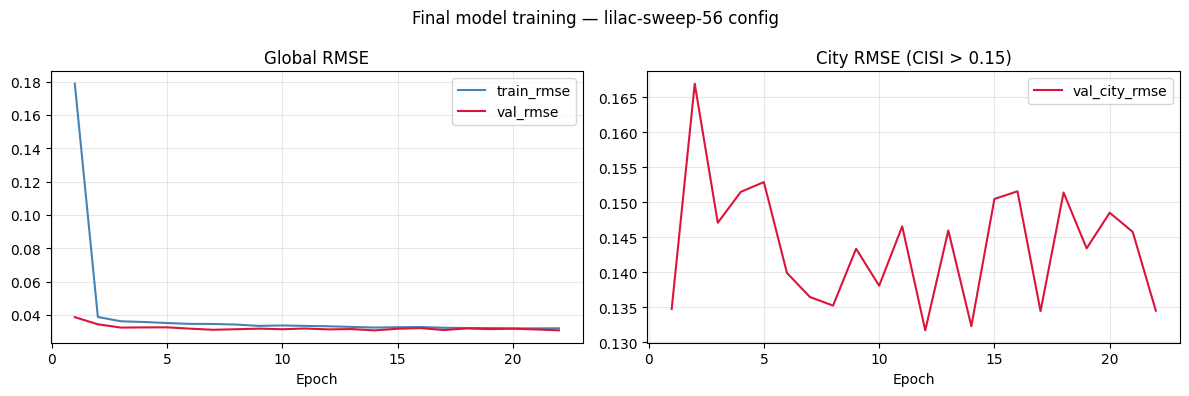

In [ ]:
# # Final training run — lilac-sweep-56 config (best val_rmse.min in sweep iutu20o7)

# FINAL_MODEL_PATH = 'final_model_lilac56.pt'

# cfg = {
#     'patch_size':    8,
#     'base_channels': 32,
#     'n_layers':      2,
#     'loss_fn':       'huber',
#     'delta':         0.05,
#     'lr':            0.00018672478544905867,
#     'weight_decay':  0.0000025576212047230037,
#     'dropout':       0.1,
#     'batch_size':    32,
# }

# set_seed(42)

# train_full = CISIDataset(gdp_path, pop_path, lc_path, cisi_path,
#                          patch_size=cfg['patch_size'], eu_mask_path=eu_mask_path, augment=True)
# val_full   = CISIDataset(gdp_path, pop_path, lc_path, cisi_path,
#                          patch_size=cfg['patch_size'], eu_mask_path=eu_mask_path, augment=False)

# cisi_vals = np.array([train_full.cisi[i, j] for i, j in train_full.valid_indices])
# high_idx  = np.where(cisi_vals > 0.15)[0]
# low_idx   = np.where(cisi_vals <= 0.15)[0]
# rng = np.random.RandomState(42)
# rng.shuffle(high_idx); rng.shuffle(low_idx)
# train_idx = np.concatenate([high_idx[:int(0.8*len(high_idx))], low_idx[:int(0.8*len(low_idx))]])
# val_idx   = np.concatenate([high_idx[int(0.8*len(high_idx)):], low_idx[int(0.8*len(low_idx)):]])
# train_ds  = Subset(train_full, train_idx)
# val_ds    = Subset(val_full,   val_idx)

# g = torch.Generator(); g.manual_seed(42)
# train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True,
#                           worker_init_fn=seed_worker, generator=g)
# val_loader   = DataLoader(val_ds,   batch_size=cfg['batch_size'], shuffle=False,
#                           worker_init_fn=seed_worker, generator=g)

# model     = CNNSweep(cfg).to(device)
# criterion = build_criterion(cfg)
# optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
# es        = EarlyStopping(patience=15, delta=0.001)

# history = {'train_rmse': [], 'val_rmse': [], 'val_city_rmse': []}

# for epoch in range(150):
#     model.train()
#     tr_preds, tr_targets = [], []
#     for inputs, targets, _ in train_loader:
#         inputs, targets_dev = inputs.to(device), targets.to(device).view(-1, 1)
#         optimizer.zero_grad()
#         out = model(inputs)
#         loss = criterion(out, targets_dev)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()
#         tr_preds.extend(out.detach().cpu().numpy().flatten())
#         tr_targets.extend(targets.numpy().flatten())

#     model.eval()
#     ep_preds, ep_targets = [], []
#     with torch.no_grad():
#         for inputs, targets, _ in val_loader:
#             ep_preds.extend(model(inputs.to(device)).cpu().numpy().flatten())
#             ep_targets.extend(targets.numpy().flatten())

#     ep_preds   = np.array(ep_preds);   ep_targets = np.array(ep_targets)
#     tr_preds   = np.array(tr_preds);   tr_targets = np.array(tr_targets)
#     ep_city    = ep_targets > 0.15

#     val_rmse      = float(np.sqrt(np.mean((ep_targets - ep_preds) ** 2)))
#     val_city_rmse = float(np.sqrt(np.mean((ep_targets[ep_city] - ep_preds[ep_city]) ** 2))) if ep_city.sum() > 10 else 999.0
#     train_rmse    = float(np.sqrt(np.mean((tr_targets - tr_preds) ** 2)))

#     history['train_rmse'].append(train_rmse)
#     history['val_rmse'].append(val_rmse)
#     history['val_city_rmse'].append(val_city_rmse)

#     print(f'Epoch {epoch+1:3d}  train_rmse={train_rmse:.4f}  val_rmse={val_rmse:.4f}  val_city_rmse={val_city_rmse:.4f}')
#     scheduler.step()
#     es(val_rmse, model)
#     if es.early_stop:
#         print('Early stopping at epoch', epoch + 1)
#         break

# # Save best weights
# model.load_state_dict(es.best_weights)
# torch.save({'model_state_dict': es.best_weights, 'config': cfg,
#             'val_rmse': min(history['val_rmse']),
#             'val_city_rmse': min(history['val_city_rmse'])}, FINAL_MODEL_PATH)
# print(f'Saved {FINAL_MODEL_PATH}')
# print(f'Best val_rmse:      {min(history["val_rmse"]):.4f}')
# print(f'Best val_city_rmse: {min(history["val_city_rmse"]):.4f}')

# # Training curves
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# epochs = list(range(1, len(history['val_rmse']) + 1))
# axes[0].plot(epochs, history['train_rmse'], label='train_rmse', color='steelblue')
# axes[0].plot(epochs, history['val_rmse'],   label='val_rmse',   color='crimson')
# axes[0].set_title('Global RMSE'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
# axes[1].plot(epochs, history['val_city_rmse'], label='val_city_rmse', color='crimson')
# axes[1].set_title('City RMSE (CISI > 0.15)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
# plt.suptitle('Final model training — lilac-sweep-56 config', fontsize=12)
# plt.tight_layout()
# plt.show()